In [1]:
import warnings

import matplotlib.pyplot as plt
import nivapy3 as nivapy
import numpy as np
import pandas as pd

warnings.simplefilter("ignore")
plt.style.use("ggplot")

# TEOTIL3 for Lillestrøm kommune
# Notebook 03: Annual mean/median concentrations

This notebook quality checks the raw water chemistry data and calculates mean/median annual concentrations at each site. The workflow is as follows:

 1. **Detect and remove outliers** (e.g. contaminated samples, lab errors). A conservative threshold is used, such that only the most extreme values are removed.
 2. To avoid bias due to limited sampling, annual means/medians are only calculated if there are **at least 12 samples per year**.
 3. **Mann-Kendall and Sen's slope tests for trends** are applied to each time series.

## 1. User options

In [2]:
# Threshold for marking outliers. Smaller values identify more outliers
out_thresh = 20

# Threshold based on number of samples per year
min_samps_per_year = 12

# Statistic for annual aggregation ('mean' or 'median')
ann_stat = 'mean'

assert ann_stat in ('mean', 'median')

## 2. Sites of interest

In [3]:
# Read site data
xl_path = r"../data/lillestrom_monitoring_sites.xlsx"
stn_df = pd.read_excel(xl_path, sheet_name="chem_stns")
stn_df

,catchment,station_id,station_name,regine,wb_id,wb_name,lon,lat,comment
0,Sagelva,002-46599,Sagelva ved Skjetten bro (F3),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,11.01695,59.95850,Downstream
1,Sagelva,002-63540,Fjellhammarelva (F10),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,10.99617,59.94419,Slightly upstream
2,Nitelva,002-30586,Rud Nitelva (N8),002.CB0,002-3891-R,Nedre Nitelva,11.05700,59.94553,Downstream
3,Nitelva,002-30578,Kjellerholen Nitelva (N6),002.CC0,002-1638-R,Nitelva Slattum-Kjeller,11.00850,59.97925,Slightly upstream
4,Leira,002-29659,Leira ved Borgen bru (L5),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.10032,59.95036,Downstream
5,Leira,002-30584,Leira ved Leirsund (L8),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.08849,59.99755,Slightly upstream
6,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,002.D2Z,002-3659-R,Rømua,11.22099,60.02163,Downstream
7,Jeksla,002-30593,"Jeksla ved Haugli, J14",002.CAA0,002-599-R,Jeksla,11.10637,60.00199,Downstream. Small part of regine
8,Åa,002-60929,Fossåa ved Sylta (ÅA1),002.D3Z,002-3685-R,Fossåa,11.30018,59.99209,Downstream
9,Åa,002-60963,Sloråa ved Bruvollen (ÅA3),002.D3Z,002-3687-R,Sloråa,11.34807,59.98512,Upstream. North branch


## 3. Water chemistry data

In [4]:
# Raw chem from Vannmiljø
xl_path = r"../data/vannmiljo_data_stations.xlsx"
wc_df = pd.read_excel(xl_path, sheet_name="data_wide")

# Check all samples are from near the surface
if (wc_df['upper_depth'].max() > 2) or (wc_df['lower_depth'].max() > 2):
    raise ValueError("Some samples are deeper than 2 m.")

# Average samples over depth
id_cols = ["station_code", "station_name", "sample_date"]
val_cols = [col for col in wc_df.columns if col.endswith("g/l")]
wc_df = wc_df[id_cols + val_cols].groupby(id_cols).mean().reset_index()

wc_df.head()

,station_code,station_name,sample_date,NH4_µg/l,TOTN_µg/l,SRP_µg/l,TRP_µg/l,DIP_µg/l,TIP_µg/l,TDP_µg/l,TOTP_µg/l,SS_mg/l,TOC_mg/l,NO3_µg/l
0,002-28960,Rømua ved Lørenfallet - RØM1,1990-04-30,NaN,1790.0,NaN,NaN,16.0,NaN,NaN,54.0,22.0,7.7,NaN
1,002-28960,Rømua ved Lørenfallet - RØM1,1990-05-14,NaN,1080.0,NaN,NaN,8.0,NaN,NaN,34.0,6.8,5.9,NaN
2,002-28960,Rømua ved Lørenfallet - RØM1,1990-05-28,NaN,1430.0,NaN,NaN,6.0,NaN,NaN,34.0,14.0,4.2,NaN
3,002-28960,Rømua ved Lørenfallet - RØM1,1990-06-11,NaN,1100.0,NaN,NaN,1.0,NaN,NaN,40.0,10.0,4.5,NaN
4,002-28960,Rømua ved Lørenfallet - RØM1,1990-06-25,NaN,2260.0,NaN,NaN,2.0,NaN,NaN,65.0,24.0,4.7,NaN


### 3.1. Plot raw data

With "outliers" marked in red.

In [5]:
# Plot raw concs
col_order = [
    "TOTN_µg/l",
    "NO3_µg/l",
    "NH4_µg/l",
    "TOTP_µg/l",
    "SRP_µg/l",
    "TRP_µg/l",
    "DIP_µg/l",
    "TIP_µg/l",
    "TDP_µg/l",
    "SS_mg/l",
    "TOC_mg/l",
]
for stn_id, stn_wc_df in wc_df.groupby("station_code"):
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 15), sharex=True)
    axes = axes.flatten()
    fig.delaxes(axes[-1])

    stn_wc_df = stn_wc_df.sort_values("sample_date")
    for idx, par in enumerate(col_order):
        stn_wc_df["outlier"] = nivapy.stats.double_mad_from_median(
            stn_wc_df[par], thresh=out_thresh
        )
        stn_wc_df["outlier"] = ["r" if i else "k" for i in stn_wc_df["outlier"]]
        axes[idx].plot(stn_wc_df["sample_date"], stn_wc_df[par], "k-")
        axes[idx].scatter(
            stn_wc_df["sample_date"],
            stn_wc_df[par],
            c=stn_wc_df["outlier"].tolist(),
        )
        axes[idx].set_title(par)
    fig.suptitle(stn_id)
    plt.tight_layout()
    png_path = f"../plots/concs/station_{stn_id}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close()

Looking at the raw data for each site, we have:

 * Consistent modelling of TOTN, TOTP, SS and TOC at most sites.
 * Limited monitoring of NH4 and very little data for NO3. This makes it difficult to reliably estimate DIN from monitored data.
 * Inconsistent monitoring of P fractions (a mixture of SRP, TRP, DIP, TIP and TDP, depending on the site, contractor and time period).

Based on this, I think it makes sense to use TOTN, TOTP, SS and TOC for trend tests and evaluation of TEOTIL. Estimates of monitored fluxes of fractions of N and P will not be reliable due to inconsistent monitoring.

### 3.2. Outliers

The plots below show the raw series for each site, with outliers marked in red.

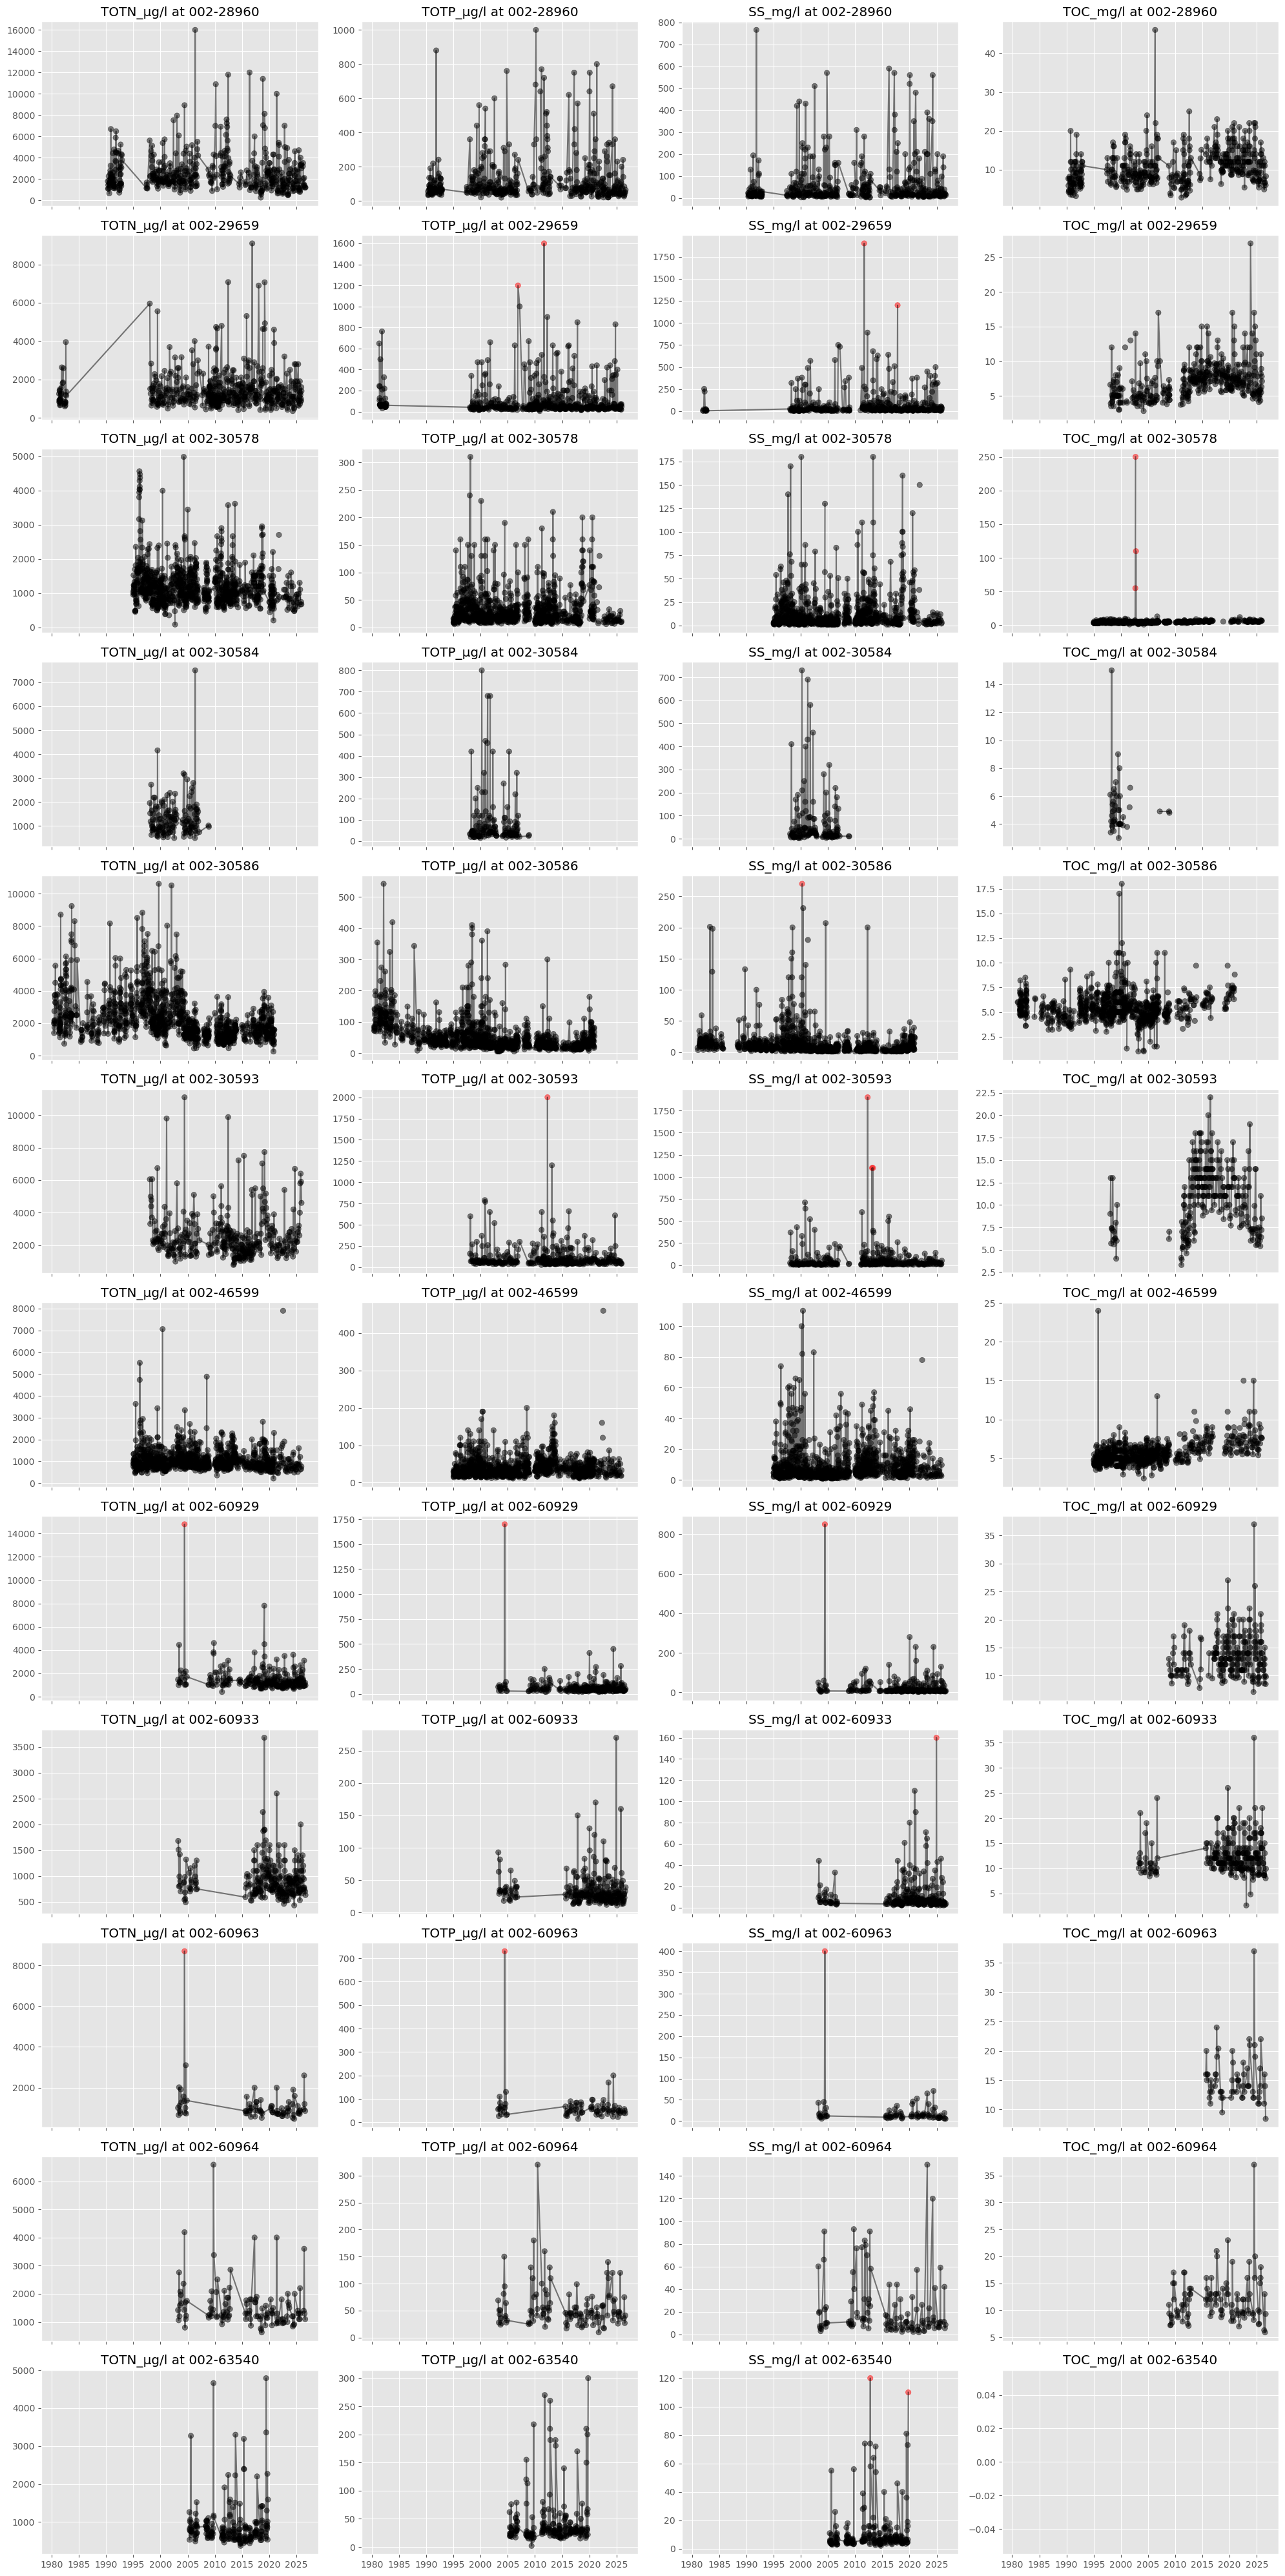

In [6]:
# Plot outliers
col_order = [
    "TOTN_µg/l",
    "TOTP_µg/l",
    "SS_mg/l",
    "TOC_mg/l",
]
fig, axes = plt.subplots(nrows=len(stn_df), ncols=4, figsize=(20, 40), sharex=True)
for row_idx, (stn_id, stn_wc_df) in enumerate(wc_df.groupby("station_code")):
    stn_wc_df = stn_wc_df.sort_values("sample_date")
    for col_idx, par in enumerate(col_order):
        stn_wc_df["outlier"] = nivapy.stats.double_mad_from_median(
            stn_wc_df[par], thresh=out_thresh
        )
        stn_wc_df["outlier"] = ["r" if i else "k" for i in stn_wc_df["outlier"]]
        axes[row_idx, col_idx].plot(
            stn_wc_df["sample_date"], stn_wc_df[par], "k-", alpha=0.5
        )
        axes[row_idx, col_idx].scatter(
            stn_wc_df["sample_date"],
            stn_wc_df[par],
            c=stn_wc_df["outlier"].tolist(),
            alpha=0.5,
        )
        axes[row_idx, col_idx].set_title(f"{par} at {stn_id}")
    plt.tight_layout()
png_path = r"../plots/concs/all_stations_main_pars.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")

In [7]:
# Remove outliers
val_cols = [
    "TOTN_µg/l",
    "TOTP_µg/l",
    "SS_mg/l",
    "TOC_mg/l",
]
df_list = []
for stn_id, stn_wc_df in wc_df.groupby("station_code"):
    stn_wc_df = stn_wc_df.sort_values("sample_date")[id_cols + val_cols]
    for par in val_cols:
        stn_wc_df["outlier"] = nivapy.stats.double_mad_from_median(
            stn_wc_df[par], thresh=out_thresh
        )
        stn_wc_df.loc[stn_wc_df["outlier"], par] = np.nan
        del stn_wc_df["outlier"]
    df_list.append(stn_wc_df)
clean_wc_df = pd.concat(df_list, axis="rows")
clean_wc_df.head()

,station_code,station_name,sample_date,TOTN_µg/l,TOTP_µg/l,SS_mg/l,TOC_mg/l
0,002-28960,Rømua ved Lørenfallet - RØM1,1990-04-30,1790.0,54.0,22.0,7.7
1,002-28960,Rømua ved Lørenfallet - RØM1,1990-05-14,1080.0,34.0,6.8,5.9
2,002-28960,Rømua ved Lørenfallet - RØM1,1990-05-28,1430.0,34.0,14.0,4.2
3,002-28960,Rømua ved Lørenfallet - RØM1,1990-06-11,1100.0,40.0,10.0,4.5
4,002-28960,Rømua ved Lørenfallet - RØM1,1990-06-25,2260.0,65.0,24.0,4.7


## 3.3. Filter based on sampling frequency and calculate annual means/medians

In [8]:
# Get mask for sampling frequency
clean_wc_df["year"] = clean_wc_df["sample_date"].dt.year
group = clean_wc_df.groupby(["station_code", "station_name", "year"])
counts = group[val_cols].count()
valid_mask = counts >= min_samps_per_year

# Annual means/medians where freq > min_freq
if ann_stat == 'mean':
    ann_df = group[val_cols].mean()
else:
    ann_df = group[val_cols].median()
ann_df = (
    ann_df.where(valid_mask)
    .reset_index()
    .sort_values(["station_code", "year"])
    .dropna(subset=val_cols, how="all")
)

# Filter raw data based on sampling frequency
counts_long = counts.reset_index().melt(
    id_vars=["station_code", "station_name", "year"],
    value_vars=val_cols,
    var_name="parameter",
    value_name="n_samples",
)
valid_long = counts_long[counts_long["n_samples"] >= min_samps_per_year]
valid_long = valid_long.drop(columns="n_samples")

# Convert raw data to long format
raw_long = clean_wc_df.melt(
    id_vars=id_cols + ["year"],
    value_vars=val_cols,
    var_name="parameter",
    value_name="value",
)

# Keep only valid station-year-parameter data
filtered_long = raw_long.merge(
    valid_long,
    on=["station_code", "station_name", "year", "parameter"],
    how="inner",
)

# Convert back to wide format
filt_wc_df = (
    filtered_long.pivot_table(
        index=id_cols + ["year"],
        columns="parameter",
        values="value",
    )
    .reset_index()
    .sort_values(["station_code", "sample_date"])
    .dropna(subset=val_cols, how="all")
)

print(f"Annual {ann_stat}s:")
display(ann_df.head())

print("\nFiltered raw data:")
display(filt_wc_df.head())

Annual means:


,station_code,station_name,year,TOTN_µg/l,TOTP_µg/l,SS_mg/l,TOC_mg/l
0,002-28960,Rømua ved Lørenfallet - RØM1,1990,2022.636364,76.363636,23.186364,7.272727
1,002-28960,Rømua ved Lørenfallet - RØM1,1991,2625.000000,101.571429,53.446429,8.292857
2,002-28960,Rømua ved Lørenfallet - RØM1,1992,2546.538462,85.461538,28.865385,8.213462
4,002-28960,Rømua ved Lørenfallet - RØM1,1998,3034.444444,105.222222,30.961111,10.533333
5,002-28960,Rømua ved Lørenfallet - RØM1,1999,2126.111111,144.277778,86.000000,NaN



Filtered raw data:


parameter,station_code,station_name,sample_date,year,SS_mg/l,TOC_mg/l,TOTN_µg/l,TOTP_µg/l
0,002-28960,Rømua ved Lørenfallet - RØM1,1990-04-30,1990,22.0,7.7,1790.0,54.0
1,002-28960,Rømua ved Lørenfallet - RØM1,1990-05-14,1990,6.8,5.9,1080.0,34.0
2,002-28960,Rømua ved Lørenfallet - RØM1,1990-05-28,1990,14.0,4.2,1430.0,34.0
3,002-28960,Rømua ved Lørenfallet - RØM1,1990-06-11,1990,10.0,4.5,1100.0,40.0
4,002-28960,Rømua ved Lørenfallet - RØM1,1990-06-25,1990,24.0,4.7,2260.0,65.0


### 3.4. Tests for trends

The code below plots annual mean/median concentrations for each site and also applies the Mann-Kendall and Sen's slope tests for trends to the annual data.

 * Solid black lines show significant trends ($p \leq 0.05$).
 * Dashed lines show non-significant trends

,catchment,station_id,station_name,comment,par,mk_trend,mk_pval,sslp,sslp_ub,sslp_lb
0,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,Downstream,TOTN_µg/l,no trend,0.428178,-9.196833,12.274798,-26.226780
1,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,Downstream,TOTP_µg/l,no trend,0.492290,0.247565,2.390093,-1.082222
2,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,Downstream,SS_mg/l,no trend,0.315573,0.698930,1.865494,-0.552249
3,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,Downstream,TOC_mg/l,increasing,0.003362,0.128487,0.199756,0.058632
4,Leira,002-29659,Leira ved Borgen bru (L5),Downstream,TOTN_µg/l,no trend,0.984238,-0.671547,7.617582,-10.055556
5,Leira,002-29659,Leira ved Borgen bru (L5),Downstream,TOTP_µg/l,no trend,0.646498,-0.417929,1.294071,-1.600694
6,Leira,002-29659,Leira ved Borgen bru (L5),Downstream,SS_mg/l,no trend,0.981367,0.035488,1.550976,-2.135000
7,Leira,002-29659,Leira ved Borgen bru (L5),Downstream,TOC_mg/l,increasing,0.007084,0.126418,0.176429,0.053431
8,Nitelva,002-30578,Kjellerholen Nitelva (N6),Slightly upstream,TOTN_µg/l,no trend,0.078219,-9.034664,0.545833,-16.794529
9,Nitelva,002-30578,Kjellerholen Nitelva (N6),Slightly upstream,TOTP_µg/l,no trend,0.358743,-0.371644,0.369792,-0.857337


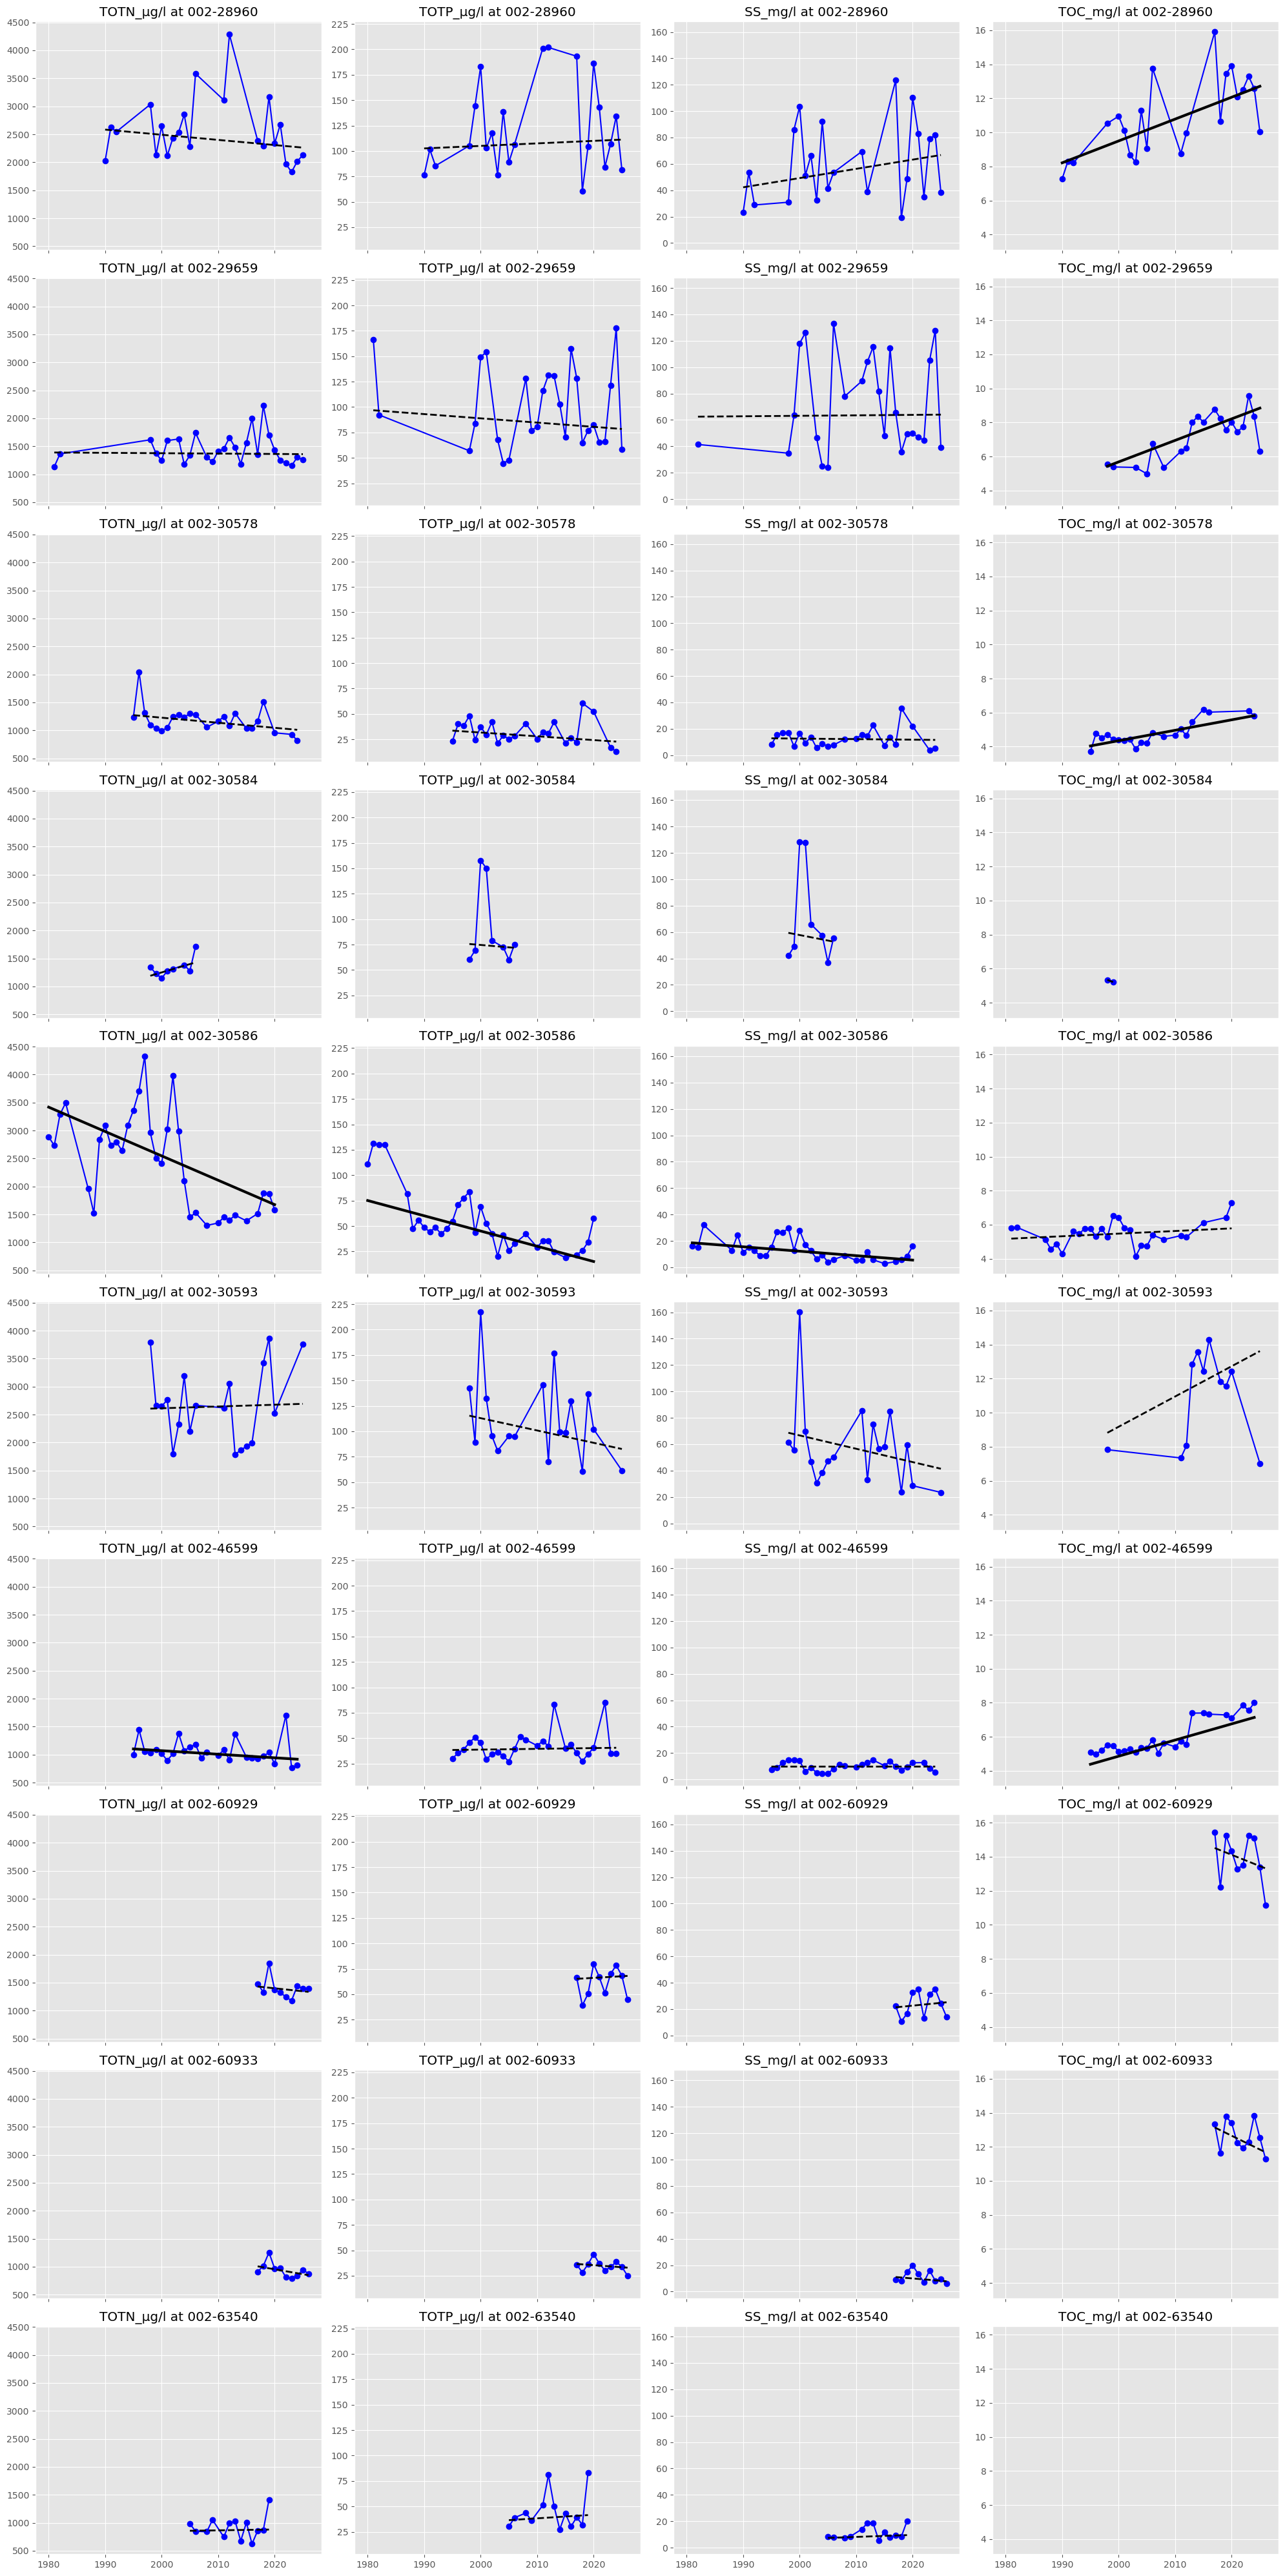

In [9]:
col_order = [
    "TOTN_µg/l",
    "TOTP_µg/l",
    "SS_mg/l",
    "TOC_mg/l",
]
fig, axes = plt.subplots(
    nrows=len(ann_df["station_code"].unique()),
    ncols=4,
    figsize=(20, 40),
    sharex=True,
    sharey="col",
)

res_dict = {
    "station_id": [],
    "par": [],
    "mk_trend": [],
    "mk_pval": [],
    "sslp": [],
    "sslp_ub": [],
    "sslp_lb": [],
}
for row_idx, (stn_id, stn_wc_df) in enumerate(ann_df.groupby("station_code")):
    stn_wc_df = stn_wc_df.sort_values("year")
    for col_idx, par in enumerate(col_order):
        stn_par_df = stn_wc_df[["year", par]].dropna(subset=par)

        if len(stn_par_df) > 1:
            # Test for trends
            mk_df = nivapy.stats.mk_test(stn_par_df, par, alpha=0.05)
            res_df, sen_df = nivapy.stats.sens_slope(
                stn_par_df, par, index_col="year", alpha=0.05
            )

            # Extract results
            trend = mk_df.loc["trend", "value"]
            pval = mk_df.loc["p", "value"]
            sslp = res_df.loc["sslp"]["value"]
            icpt = res_df.loc["icpt"]["value"]
            lb = res_df.loc["lb"]["value"]
            ub = res_df.loc["ub"]["value"]

            # Add to results
            res_dict["station_id"].append(stn_id)
            res_dict["par"].append(par)
            res_dict["mk_trend"].append(trend)
            res_dict["mk_pval"].append(pval)
            res_dict["sslp"].append(sslp)
            res_dict["sslp_ub"].append(ub)
            res_dict["sslp_lb"].append(lb)

            # Plot
            axes[row_idx, col_idx].plot(stn_par_df["year"], stn_par_df[par], "bo-")
            if trend != "no trend":
                axes[row_idx, col_idx].plot(
                    sen_df.index.values,
                    sen_df.index.values * sslp + icpt,
                    "k-",
                    lw=3,
                )
            else:
                axes[row_idx, col_idx].plot(
                    sen_df.index.values,
                    sen_df.index.values * sslp + icpt,
                    "k--",
                    lw=2,
                )
        axes[row_idx, col_idx].set_title(f"{par} at {stn_id}")
    plt.tight_layout()
png_path = r"../plots/concs/all_stations_avg_concs.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")

# Merge results
stat_df = pd.DataFrame(res_dict)
stat_df = pd.merge(
    stn_df[["catchment", "station_id", "station_name", "comment"]],
    stat_df,
    how="right",
    on="station_id",
)

stat_df

In [10]:
# Save
xl_path = r"../data/cleaned_concs_stations.xlsx"
with pd.ExcelWriter(xl_path) as writer:
    filt_wc_df.to_excel(writer, sheet_name="cleaned_chem", index=False)
    ann_df.to_excel(writer, sheet_name="annual_avgs", index=False)
    stat_df.to_excel(writer, sheet_name="conc_trends", index=False)